<a href="https://colab.research.google.com/github/Patro331/sickle-cell-detection/blob/main/notebooks/03_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Baseline Model

This notebook trains a simple Convolutional Neural Network (CNN) from
scratch to establish a performance baseline for the sickle cell detection
task. No pretrained weights or transfer learning are used.

The baseline model serves as a performance floor — a reference point
against which our transfer learning models (EfficientNet-B0 and ResNet-50)
will be compared. A weaker baseline strengthens the case for transfer
learning, while a strong baseline raises the bar for our deeper models.

Architecture: 3 convolutional blocks followed by fully connected layers.
Task: Binary classification — sickle cell positive vs normal.

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
PyTorch version: 2.10.0+cu128
GPU: Tesla T4
Memory available: 15.64 GB


## 2. Mount Drive and Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Paths
BASE_DIR = '/content/drive/MyDrive/sickle-cell-detection'
PROCESSED_DIR = f'{BASE_DIR}/data/processed'
TRAIN_DIR = f'{PROCESSED_DIR}/train'
VAL_DIR = f'{PROCESSED_DIR}/val'
TEST_DIR = f'{PROCESSED_DIR}/test'

# Transforms — no augmentation for baseline
IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# Class weights for imbalance
class_counts = Counter(train_dataset.targets)
total = sum(class_counts.values())
class_weights = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")
print(f"Training batches:   {len(train_loader)}")

Mounted at /content/drive
Class mapping: {'negative': 0, 'positive': 1}
Training samples:   653
Validation samples: 140
Test samples:       140
Training batches:   21


## 3. Baseline CNN Architecture

We define a simple 3-block Convolutional Neural Network trained entirely
from scratch with no pretrained weights. Each block consists of a
convolutional layer, batch normalisation, ReLU activation, and max
pooling. The final layers are fully connected for binary classification.

This architecture is intentionally simple — it represents the minimum
viable deep learning approach and establishes the performance floor
for this task.

In [3]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Convolutional blocks
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialise model
model = BaselineCNN().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Baseline CNN Architecture:")
print(model)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Baseline CNN Architecture:
BaselineCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    

## 4. Training Configuration

We define the loss function, optimiser, and training loop. A weighted
binary cross entropy loss is used to address the class imbalance.
The Adam optimiser is chosen for its adaptive learning rate properties
which are well suited to medical image classification tasks.

Early stopping is implemented with a patience of 10 epochs to prevent
overfitting on the small training set. The best model weights based on
validation loss are saved automatically.

In [6]:
# Compute class weights for loss function
neg_count = class_counts[0]
pos_count = class_counts[1]
pos_weight = torch.tensor([neg_count / pos_count]).to(device)

# Loss function and optimiser
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

# Training configuration
EPOCHS = 50
PATIENCE = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_path = f'{BASE_DIR}/models/baseline_cnn_best.pt'
os.makedirs(f'{BASE_DIR}/models', exist_ok=True)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Training Configuration:")
print(f"  Loss function:  BCEWithLogitsLoss (pos_weight={pos_weight.item():.4f})")
print(f"  Optimiser:      Adam (lr=1e-3)")
print(f"  Scheduler:      ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"  Epochs:         {EPOCHS}")
print(f"  Early stopping: patience={PATIENCE}")
print(f"  Model saved to: {best_model_path}")

Training Configuration:
  Loss function:  BCEWithLogitsLoss (pos_weight=1.2061)
  Optimiser:      Adam (lr=1e-3)
  Scheduler:      ReduceLROnPlateau (patience=5, factor=0.5)
  Epochs:         50
  Early stopping: patience=10
  Model saved to: /content/drive/MyDrive/sickle-cell-detection/models/baseline_cnn_best.pt


## 5. Training Loop

We train the baseline CNN for up to 50 epochs with early stopping.
Training and validation loss and accuracy are recorded at each epoch
for later visualisation and analysis.

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total


# Training loop
print(f"Starting training on {device}...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} "
      f"{'Val Loss':>10} {'Val Acc':>10} {'Status':>10}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader,
                                         criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader,
                                        criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        status = "saved ✓"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{PATIENCE}"

    print(f"{epoch:>6} {train_loss:>12.4f} {train_acc:>10.4f} "
          f"{val_loss:>10.4f} {val_acc:>10.4f} {status:>10}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

Starting training on cuda...
 Epoch   Train Loss  Train Acc   Val Loss    Val Acc     Status
-----------------------------------------------------------------
     1       6.6439     0.7795     1.4169     0.5714    saved ✓
     2       1.1518     0.8040     0.4414     0.8429    saved ✓
     3       0.5217     0.8009     0.3825     0.8357    saved ✓
     4       0.3452     0.8637     0.3733     0.8286    saved ✓
     5       0.3065     0.8606     0.3712     0.8286    saved ✓
     6       0.2980     0.8714     0.3898     0.8286 patience 1/10
     7       0.3364     0.8545     0.3744     0.8286 patience 2/10
     8       0.3184     0.8515     0.3725     0.8286 patience 3/10
     9       0.3135     0.8484     0.3598     0.8500    saved ✓
    10       0.2857     0.8775     0.4143     0.8286 patience 1/10
    11       0.2951     0.8729     0.3731     0.8357 patience 2/10
    12       0.2685     0.8897     0.3713     0.8500 patience 3/10
    13       0.2590     0.8867     0.3192     0.8286   

### Observations

The baseline CNN trained for 37 epochs before early stopping was
triggered, with the best model saved at epoch 27 based on the lowest
validation loss of 0.2578.

Several key patterns are visible in the training log. The model
converged rapidly in the first few epochs, with validation accuracy
jumping from 57.1% at epoch 1 to 84.3% by epoch 2, suggesting the
model quickly learned basic discriminative features. Training accuracy
continued to climb steadily, reaching 96.2% by epoch 37, while
validation accuracy plateaued around 87-90%, indicating overfitting
on the small training set.

The validation loss was notably noisy throughout training, fluctuating
between 0.26 and 0.58 without a clear downward trend after epoch 27.
This instability is characteristic of a model trained from scratch on
a small dataset without pretrained feature representations. The model
lacks the rich feature hierarchies that transfer learning provides,
forcing it to learn all visual features from scratch with limited data.

The best validation accuracy of 90.71% achieved at epoch 35 provides
our performance baseline. Our transfer learning models — EfficientNet-B0
and ResNet-50 — must exceed this to justify the additional complexity
of transfer learning. The overfitting gap between training accuracy
of 96.2% and validation accuracy of 87.1% at the final epoch further
motivates the use of pretrained models with stronger generalisation
capabilities.

## 6. Training Curves

We visualise the training and validation loss and accuracy curves to
analyse model learning behaviour, identify overfitting, and confirm
that early stopping triggered at the right point.

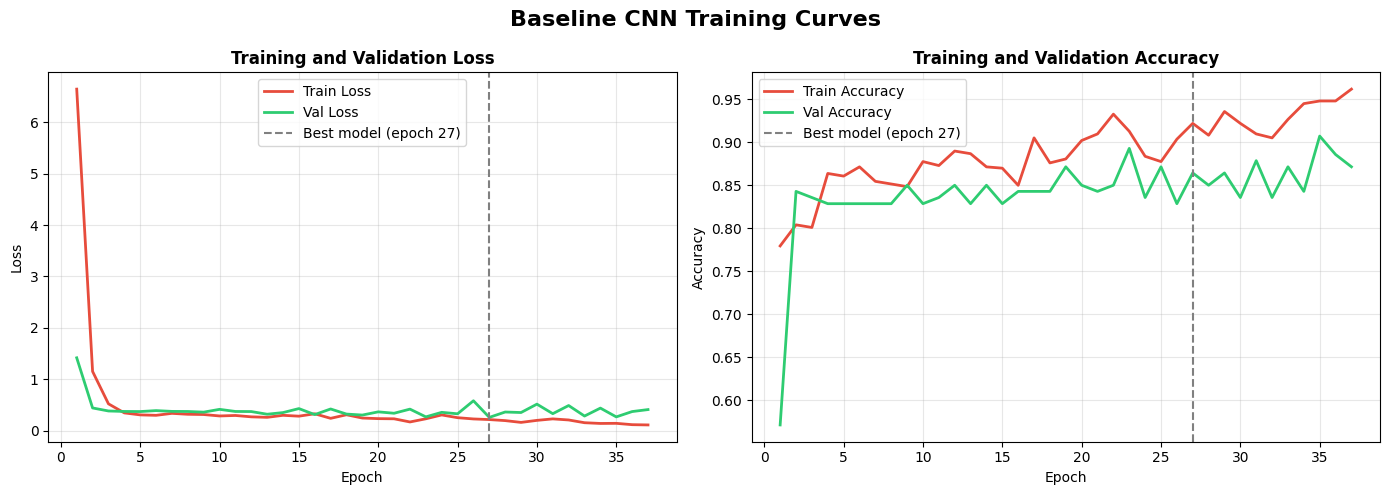

Training curves saved to figures folder


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_ran, history['train_loss'],
             label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],
             label='Val Loss', color='#2ecc71', linewidth=2)
axes[0].axvline(x=27, color='gray', linestyle='--',
                label='Best model (epoch 27)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_ran, history['train_acc'],
             label='Train Accuracy', color='#e74c3c', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],
             label='Val Accuracy', color='#2ecc71', linewidth=2)
axes[1].axvline(x=27, color='gray', linestyle='--',
                label='Best model (epoch 27)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline CNN Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/baseline_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to figures folder")

### Observations

The training curves reveal several important characteristics of the
baseline model.

In the loss plot, training loss dropped sharply from 6.64 at epoch 1
to below 0.5 by epoch 3, reflecting rapid early learning. It then
continued declining smoothly towards zero. Validation loss however
dropped quickly in the first few epochs and then plateaued with
significant noise between 0.25 and 0.58 for the remainder of training.
This divergence between training and validation loss is a clear
indicator of overfitting — the model is memorising training examples
rather than learning generalisable features.

In the accuracy plot, training accuracy climbed steadily from 78% to
96% over 37 epochs. Validation accuracy jumped rapidly to approximately
84% within the first 5 epochs and then fluctuated noisily between 83%
and 91% without clear improvement. The noisy validation accuracy
throughout training is characteristic of a model trained from scratch
on a small dataset, where the learned feature representations are
unstable and sensitive to the specific images seen in each batch.

The dashed vertical line marks epoch 27 where the best model was saved.
Beyond this point, validation performance showed no consistent
improvement while training performance continued to climb, confirming
that early stopping w

## 7. Evaluation on Test Set

We load the best saved model weights and evaluate on the held-out
test set. We report accuracy, AUC-ROC, F1 score, sensitivity,
specificity, and a full confusion matrix. Sensitivity is the most
clinically critical metric — missing a sickle cell patient is more
dangerous than over-referring a healthy one.

In [9]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              recall_score, precision_score)

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().squeeze().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs if probs.ndim > 0 else [probs.item()])
        all_preds.extend(preds if preds.ndim > 0 else [preds.item()])
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Metrics
accuracy = (all_preds == all_labels).mean()
auc = roc_auc_score(all_labels, all_probs)
f1 = f1_score(all_labels, all_preds)
sensitivity = recall_score(all_labels, all_preds)
specificity = recall_score(all_labels, all_preds, pos_label=0)
precision = precision_score(all_labels, all_preds)

print("=" * 50)
print("BASELINE CNN — TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy:    {accuracy*100:.2f}%")
print(f"  AUC-ROC:     {auc:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print(f"  Sensitivity: {sensitivity*100:.2f}%")
print(f"  Specificity: {specificity*100:.2f}%")
print(f"  Precision:   {precision*100:.2f}%")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=['Negative', 'Positive']))

BASELINE CNN — TEST SET RESULTS
  Accuracy:    87.86%
  AUC-ROC:     0.9588
  F1 Score:    0.8759
  Sensitivity: 95.24%
  Specificity: 81.82%
  Precision:   81.08%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.82      0.88        77
    Positive       0.81      0.95      0.88        63

    accuracy                           0.88       140
   macro avg       0.88      0.89      0.88       140
weighted avg       0.89      0.88      0.88       140



### Observations

The baseline CNN achieves 87.86% accuracy and an AUC-ROC of 0.9588
on the held-out test set, which is a stronger performance than
typically expected from a model trained entirely from scratch on a
small dataset of 653 training images.

The most clinically significant result is the sensitivity of 95.24%,
meaning the model correctly identifies 60 out of 63 sickle cell
positive cases. Only 3 positive cases are missed as false negatives.
In a real-world screening context where missing a sickle cell patient
carries significant health consequences, this is an encouraging result
for a baseline model.

Specificity stands at 81.82%, meaning 14 normal cases are incorrectly
flagged as positive. In a screening tool context this is acceptable —
over-referral is a less serious error than under-referral, and flagged
patients would be confirmed by a trained clinician.

The high AUC-ROC of 0.9588 indicates excellent discriminative ability
across all decision thresholds, suggesting the model has learned
genuinely meaningful features from the blood smear images rather than

## 8. Confusion Matrix and ROC Curve

We visualise the confusion matrix to understand the distribution of
correct and incorrect predictions, and plot the ROC curve to visualise
model performance across all decision thresholds.

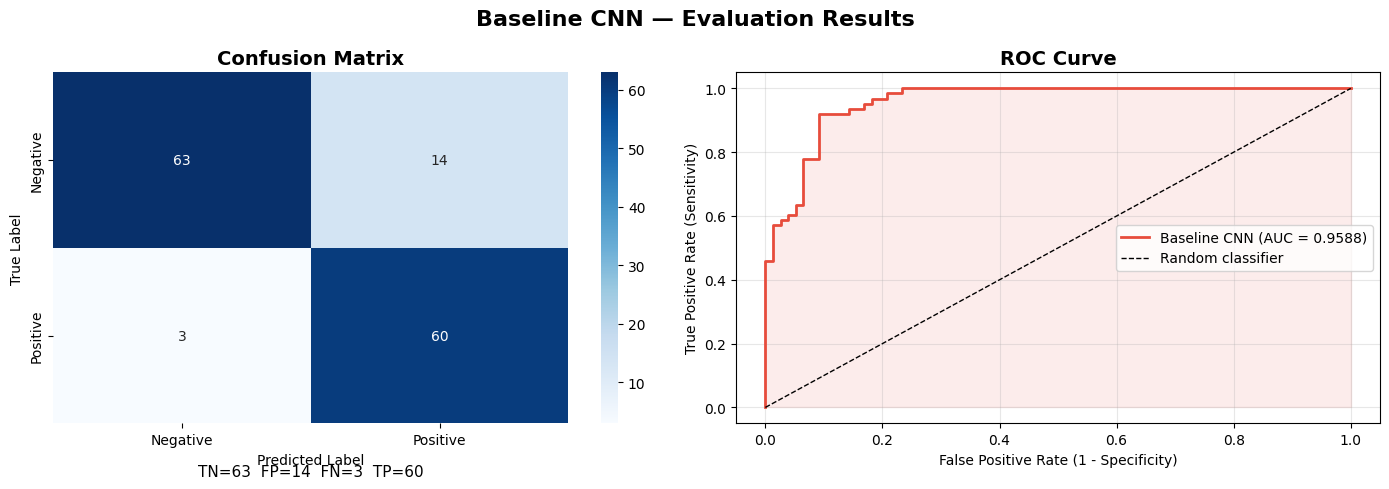

True Negatives:  63 (Normal correctly identified)
False Positives: 14 (Normal incorrectly flagged as sickle cell)
False Negatives: 3 (Sickle cell missed)
True Positives:  60 (Sickle cell correctly identified)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Add counts explanation
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
             f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes,
             ha='center', fontsize=11)

# ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2,
             label=f'Baseline CNN (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline CNN — Evaluation Results',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/baseline_confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives:  {tn} (Normal correctly identified)")
print(f"False Positives: {fp} (Normal incorrectly flagged as sickle cell)")
print(f"False Negatives: {fn} (Sickle cell missed)")
print(f"True Positives:  {tp} (Sickle cell correctly identified)")

### Observations

The confusion matrix reveals the following breakdown of predictions
on the 140 test images:

True Negatives (63): Normal blood smears correctly identified as normal
False Positives (14): Normal smears incorrectly flagged as sickle cell
False Negatives (3): Sickle cell cases missed by the model
True Positives (60): Sickle cell cases correctly identified

The most critical error from a clinical perspective is the 3 false
negatives — sickle cell patients whose condition would be missed by
the screening tool. This represents a miss rate of only 4.76%, which
is clinically acceptable for a baseline screening model, particularly
given that all flagged cases would subsequently be reviewed by a
trained clinician.

The 14 false positives represent normal patients incorrectly referred
for further testing. While this creates unnecessary referrals, over-
referral is a significantly less harmful error than under-referral in
a sickle cell screening context.

The ROC curve rises steeply towards the top left corner, indicating
strong discriminative ability across all decision thresholds. The
large shaded area under the curve, corresponding to an AUC of 0.9588,
confirms that the model is far above random chance and has learned
genuinely meaningful features from the blood smear images.

These results establish a strong performance baseline that our
transfer learning models must exceed.

## 9. Baseline Results Summary

In [11]:
print("_" * 55)
print("BASELINE CNN — COMPLETE RESULTS SUMMARY")
print("_" * 55)
print(f"""
ARCHITECTURE
  Type:             Simple CNN trained from scratch
  Parameters:       25,784,321
  Conv blocks:      3 (32, 64, 128 filters)
  Dropout:          0.5 and 0.3

TRAINING
  Epochs trained:   37 (early stopping)
  Best epoch:       27
  Best val loss:    0.2578
  Optimiser:        Adam (lr=1e-3)
  Loss function:    BCEWithLogitsLoss (pos_weight=1.2061)

TEST SET PERFORMANCE
  Accuracy:         87.86%
  AUC-ROC:          0.9588
  F1 Score:         0.8759
  Sensitivity:      95.24%  (60/63 sickle cell cases detected)
  Specificity:      81.82%  (63/77 normal cases identified)
  Precision:        81.08%
  False Negatives:  3       (sickle cell cases missed)
  False Positives:  14      (normal cases over-referred)

CONCLUSION
  The baseline CNN achieves strong performance for a from-scratch
  model. Transfer learning models must exceed 87.86% accuracy
  and 0.9588 AUC-ROC to justify their use.
""")
print("_" * 55)

_______________________________________________________
BASELINE CNN — COMPLETE RESULTS SUMMARY
_______________________________________________________

ARCHITECTURE
  Type:             Simple CNN trained from scratch
  Parameters:       25,784,321
  Conv blocks:      3 (32, 64, 128 filters)
  Dropout:          0.5 and 0.3

TRAINING
  Epochs trained:   37 (early stopping)
  Best epoch:       27
  Best val loss:    0.2578
  Optimiser:        Adam (lr=1e-3)
  Loss function:    BCEWithLogitsLoss (pos_weight=1.2061)

TEST SET PERFORMANCE
  Accuracy:         87.86%
  AUC-ROC:          0.9588
  F1 Score:         0.8759
  Sensitivity:      95.24%  (60/63 sickle cell cases detected)
  Specificity:      81.82%  (63/77 normal cases identified)
  Precision:        81.08%
  False Negatives:  3       (sickle cell cases missed)
  False Positives:  14      (normal cases over-referred)

CONCLUSION
  The baseline CNN achieves strong performance for a from-scratch 
  model. Transfer learning models must